# 🎭 Face2FaceRHO — Colab 실행 가이드 (Python 3.12 / PyTorch 2.10 / CUDA 12.8 호환)

> ⚠️ **런타임 설정 먼저!** 상단 메뉴 → 런타임 → 런타임 유형 변경 → **GPU (T4)** 선택

---
**v2 변경사항**: 코랩 최신 환경(Python 3.12, PyTorch 2.10+cu128) 기준으로 수정
- torch 버전 고정 제거 → 코랩 기본 설치 버전 사용
- pytorch3d 소스 빌드로 변경

## STEP 0 — 환경 확인

In [ ]:
!nvidia-smi
import torch, sys
print(f"Python   : {sys.version}")
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.version.cuda}")
print(f"GPU 사용 : {torch.cuda.is_available()}")

Tue Mar 24 06:03:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## STEP 1 — 레포 클론

In [ ]:
import os

if not os.path.exists('/content/Face2FaceRHO'):
    !git clone https://github.com/NetEase-GameAI/Face2FaceRHO.git
else:
    print("이미 클론됨 — 스킵")

%cd /content/Face2FaceRHO
!git submodule update --init --recursive

Cloning into 'Face2FaceRHO'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 119 (delta 8), reused 116 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (119/119), 6.61 MiB | 12.35 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/Face2FaceRHO


## STEP 2 — 기본 패키지 설치 (torch 버전 고정 없음)

In [ ]:
# torch는 이미 설치된 버전 그대로 사용
# kornia: 최신 버전으로 설치 (0.5.8은 너무 구버전)
!pip install -q kornia
!pip install -q yacs ninja trimesh
!pip install -q face-alignment==1.3.4

print("✅ 기본 패키지 설치 완료")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 38.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ 기본 패키지 설치 완료


## STEP 4 — 모델 파일 준비

> ### ⚠️ 수동 다운로드 필요 (3가지)
>
> | # | 모델 | 링크 | 저장 위치 |
> |---|------|------|----------|
> | 1 | **Pre-trained weights** | [Google Drive](https://drive.google.com/drive/folders/1eKHMevJBIvjLcVBBB2EkJwHkzN7pTLJG) | `./src/checkpoints/voxceleb_face2facerho/` |
> | 2 | **FLAME 2020** | [flame.is.tue.mpg.de](https://flame.is.tue.mpg.de/) (회원가입 필요) | `./src/external/data/generic_model.pkl` |
> | 3 | **DECA model** | [DECA GitHub](https://github.com/yfeng95/DECA) → README Downloads | `./src/external/data/deca_model.tar` |
>
> **권장**: 파일을 구글 드라이브에 업로드 후 아래 셀에서 마운트

In [ ]:
# Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, shutil

# =============================================
# ↓ 본인의 드라이브 경로로 수정하세요
DRIVE_BASE = '/content/drive/MyDrive/Face2FaceRHO_models'
# =============================================

os.makedirs('./src/checkpoints/voxceleb_face2facerho', exist_ok=True)
os.makedirs('./src/external/data', exist_ok=True)

tasks = [
    (f'{DRIVE_BASE}/voxceleb_face2facerho', './src/checkpoints/', 'dir'),
    (f'{DRIVE_BASE}/generic_model.pkl',     './src/external/data/generic_model.pkl', 'file'),
    (f'{DRIVE_BASE}/deca_model.tar',        './src/external/data/deca_model.tar', 'file'),
]

for src, dst, kind in tasks:
    if os.path.exists(src):
        if kind == 'dir':
            shutil.copytree(src, dst + os.path.basename(src), dirs_exist_ok=True)
        else:
            shutil.copy2(src, dst)
        print(f"✅ 복사 완료: {os.path.basename(src)}")
    else:
        print(f"❌ 파일 없음: {src}")

✅ 복사 완료: voxceleb_face2facerho
✅ 복사 완료: generic_model.pkl
✅ 복사 완료: deca_model.tar


In [ ]:
# 파일 존재 여부 최종 확인
checks = [
    './src/checkpoints/voxceleb_face2facerho',
    './src/external/data/generic_model.pkl',
    './src/external/data/deca_model.tar',
]
all_ok = True
for p in checks:
    ok = os.path.exists(p)
    print(f"{'✅' if ok else '❌'} {p}")
    if not ok: all_ok = False

print()
print("🚀 모든 파일 준비 완료! STEP 5로 이동하세요." if all_ok else "⛔ 위 ❌ 항목을 먼저 해결하세요.")

✅ ./src/checkpoints/voxceleb_face2facerho
✅ ./src/external/data/generic_model.pkl
✅ ./src/external/data/deca_model.tar

🚀 모든 파일 준비 완료! STEP 5로 이동하세요.


## STEP 5 — 테스트 실행 (제공된 샘플 데이터)

In [ ]:
%cd /content/Face2FaceRHO

!mkdir -p ./test_case/result

!python src/reenact.py \
    --config ./src/config/test_face2facerho.ini \
    --src_img ./test_case/source/source.jpg \
    --src_headpose ./test_case/source/original/headpose.txt \
    --src_landmark ./test_case/source/original/landmark.txt \
    --drv_headpose ./test_case/driving/original/headpose.txt \
    --drv_landmark ./test_case/driving/original/landmark.txt \
    --output_dir ./test_case/result

print("\n✅ 실행 완료")

/content/Face2FaceRHO
----------------- Options ---------------
                     name: voxceleb_face2facerho         
                  gpu_ids: [0]                           
          checkpoints_dir: ./src/checkpoints             
                    model: face2face_rho                 
              output_size: 512                           
                  isTrain: False                         
                    phase: test                          
                load_iter: -1                            
                    epoch: 105                           
            headpose_dims: 6                             
mobilev2_encoder_channels: [16, 8, 12, 28, 64, 72, 140, 280]
mobilev2_decoder_channels: [16, 8, 14, 24, 64, 96, 140, 280]
  mobilev2_encoder_layers: [1, 2, 2, 2, 2, 2, 1]         
  mobilev2_decoder_layers: [1, 2, 2, 2, 2, 2, 1]         
mobilev2_encoder_expansion_factor: [1, 6, 6, 6, 6, 6, 6]         
mobilev2_decoder_expansion_factor: [1, 6, 6, 6, 6, 6

/tmp/ipykernel_991/3603835088.py:25: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


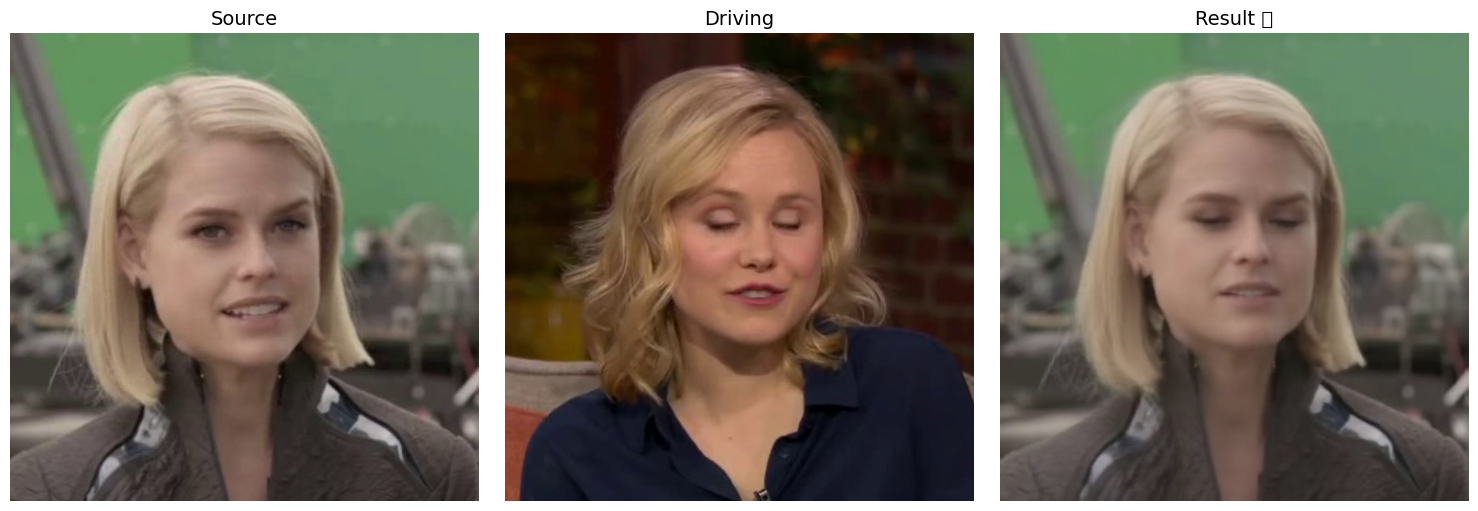

In [ ]:
# 결과 확인 (나란히 보기: source / driving / result)
import cv2, glob
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np

def show_img(path, title):
    img = cv2.imread(path)
    if img is None:
        print(f"❌ {path} 없음")
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

src  = show_img('./test_case/source/source.jpg', 'Source')
drv  = show_img('./test_case/driving/driving.jpg', 'Driving')
res  = show_img('./test_case/result/result.png', 'Result')

imgs = [(src, 'Source'), (drv, 'Driving'), (res, 'Result ✨')]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (img, title) in zip(axes, imgs):
    if img is not None:
        ax.imshow(img)
    ax.set_title(title, fontsize=14)
    ax.axis('off')
plt.tight_layout()
plt.show()

Downloading: "https://www.adrianbulat.com/downloads/python-fan/s3fd-619a316812.pth" to /root/.cache/torch/hub/checkpoints/s3fd-619a316812.pth


100%|██████████| 85.7M/85.7M [00:06<00:00, 13.8MB/s]
Downloading: "https://www.adrianbulat.com/downloads/python-fan/2DFAN4-cd938726ad.zip" to /root/.cache/torch/hub/checkpoints/2DFAN4-cd938726ad.zip
100%|██████████| 91.9M/91.9M [00:06<00:00, 14.2MB/s]


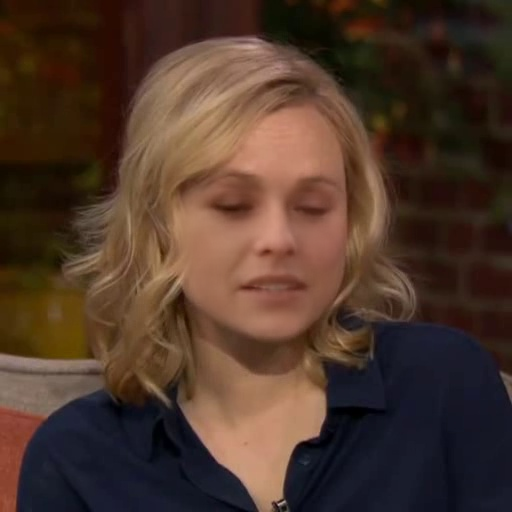

✅ 합성 완료!


In [ ]:
import cv2
import numpy as np
import face_alignment
from PIL import Image

fa = face_alignment.FaceAlignment(
    face_alignment.LandmarksType._2D, device='cuda')

def get_face_mask(img, landmarks, scale=0.9):
    hull = cv2.convexHull(landmarks.astype(np.int32)).squeeze()

    center = np.mean(hull, axis=0)
    hull_scaled = (hull - center) * scale + center
    hull_scaled = hull_scaled.astype(np.int32)

    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    cv2.fillConvexPoly(mask, hull_scaled, 255)
    mask = cv2.GaussianBlur(mask, (21, 21), 11)
    return mask

def blend_face(source_result, driving_original):

    src = cv2.imread(source_result)
    drv = cv2.imread(driving_original)
    src = cv2.resize(src, (drv.shape[1], drv.shape[0]))

    drv_rgb = cv2.cvtColor(drv, cv2.COLOR_BGR2RGB)
    lms = fa.get_landmarks(drv_rgb)

    if lms is None:
        print("❌ driving 이미지에서 얼굴을 찾지 못했습니다")
        return None

    landmarks = lms[0]
    mask = get_face_mask(drv, landmarks)

    #블렌딩
    center = (drv.shape[1] // 2, drv.shape[0] // 2)
    blended = cv2.seamlessClone(
        src, drv,
        mask,
        center,
        cv2.NORMAL_CLONE
    )

    return blended

#출력
result = blend_face(
    './test_case/result/result.png',
    './test_case/driving/driving.jpg'
)

if result is not None:
    cv2.imwrite('./test_case/result/final_blended.png', result)

    from IPython.display import Image as IPImage
    display(IPImage('./test_case/result/final_blended.png', width=512))
    print("✅ 합성 완료!")

## STEP 7 — 결과 다운로드

In [ ]:
from google.colab import files
import os

# 테스트 결과
if os.path.exists('./test_case/result/result.png'):
    files.download('./test_case/result/result.png')

# 커스텀 결과
if os.path.exists('./custom_input/result/result.png'):
    files.download('./custom_input/result/result.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>